<a href="https://colab.research.google.com/github/fviniciussilva/ape/blob/main/analise-de-desempenho-computacional(recursividade).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iniciando coleta de dados primários...

--- TABELA 1: DESEMPENHO COMPUTACIONAL (DADOS PARA O ARTIGO) ---
 N_Entrada  Tempo_Iterativo  Tempo_Recursivo  Diferenca_Percentual
         1         0.000003         0.000001            -59.854813
        51         0.000009         0.000013             33.530469
       101         0.000015         0.000024             60.190415
       151         0.000028         0.000070            151.358131
       201         0.000025         0.000064            154.042017
       251         0.000039         0.000078             99.676309
       301         0.000063         0.000115             84.418390
       351         0.000532         0.000149            -72.040985
       401         0.000070         0.000192            173.232352
       451         0.000100         0.000185             85.661934
       501         0.000120         0.000224             87.179102
       551         0.000140         0.000257             83.129619
       601         0.000

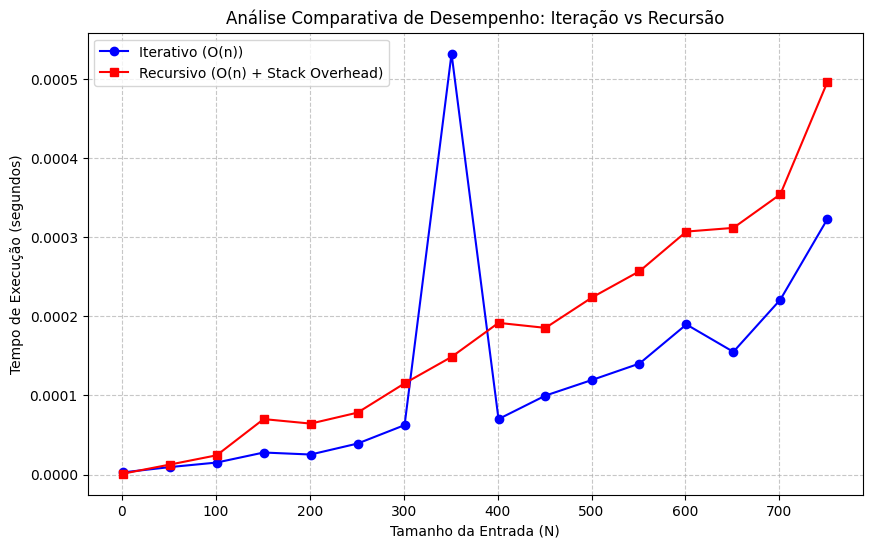

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Aumentando o limite de recursão para permitir o experimento com N maiores
sys.setrecursionlimit(2000)

def fatorial_iterativo(n):
    """Implementação iterativa do Fatorial."""
    resultado = 1
    for i in range(1, n + 1):
        resultado *= i
    return resultado

def fatorial_recursivo(n):
    """Implementação recursiva do Fatorial."""
    if n == 0 or n == 1: # Caso Base
        return 1
    else:
        return n * fatorial_recursivo(n - 1)

def rodar_experimento(limite_n, passo):
    """Coleta métricas de tempo para ambas as abordagens."""
    dados = []

    for n in range(1, limite_n + 1, passo):
        # Medindo Iterativo
        inicio_it = time.perf_counter()
        fatorial_iterativo(n)
        fim_it = time.perf_counter()
        tempo_it = fim_it - inicio_it

        # Medindo Recursivo
        inicio_rec = time.perf_counter()
        fatorial_recursivo(n)
        fim_rec = time.perf_counter()
        tempo_rec = fim_rec - inicio_rec

        dados.append({
            "N_Entrada": n,
            "Tempo_Iterativo": tempo_it,
            "Tempo_Recursivo": tempo_rec,
            "Diferenca_Percentual": ((tempo_rec - tempo_it) / tempo_it) * 100 if tempo_it > 0 else 0
        })

    return pd.DataFrame(dados)

# Execução do Experimento
print("Iniciando coleta de dados primários...")
df_resultados = rodar_experimento(limite_n=800, passo=50)

# Exibição da Tabela de Dados Finais
print("\n--- TABELA 1: DESEMPENHO COMPUTACIONAL (DADOS PARA O ARTIGO) ---")
print(df_resultados.to_string(index=False))

# Geração do Gráfico Científico
plt.figure(figsize=(10, 6))
plt.plot(df_resultados["N_Entrada"], df_resultados["Tempo_Iterativo"], label="Iterativo (O(n))", marker='o', color='blue')
plt.plot(df_resultados["N_Entrada"], df_resultados["Tempo_Recursivo"], label="Recursivo (O(n) + Stack Overhead)", marker='s', color='red')

plt.title("Análise Comparativa de Desempenho: Iteração vs Recursão")
plt.xlabel("Tamanho da Entrada (N)")
plt.ylabel("Tempo de Execução (segundos)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Salvando a figura para o Zenodo
plt.savefig("grafico.png", dpi=300)
print("\n[SUCESSO] Gráfico gerado e salvo como 'grafico.png'. Pronto para publicação.")
plt.show()